# CRM Customer Churn Intelligence Platform
## Gold Layer: EDA, Machine Learning & CRM Action Output

---

### Project Context
This notebook is part of a **Medallion Architecture** data pipeline built on the IBM Telco Customer Churn dataset. The pipeline consists of three layers:

| Layer | Purpose |
|---|---|
| 🥉 Bronze | Raw ingestion — stores data exactly as received from source |
| 🥈 Silver | Cleaned, normalized CRM tables + feature engineering |
| 🥇 Gold | ML modeling, churn scoring, and CRM retention output |

This notebook covers the **Gold Layer** — from exploratory analysis to
deploying a churn prediction model and writing actionable retention scores
back to the CRM database.

---

> **Dataset:** [IBM Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
> **Author:** Yonathan Hary Hutagalung 
> **Last Updated:** June 2026

---

## Business Problem

A telecommunications company is experiencing **significant customer churn**,
where customers cancel their subscription and switch to a competitor.
Acquiring a new customer costs **5–7× more** than retaining an existing one,
making churn one of the most costly business problems in the telecom industry.

### Business Questions
1. **Who** is likely to churn in the next billing cycle?
2. **Why** are they churning — what are the key risk drivers?
3. **What action** should the CRM team take for each at-risk customer?

### Business Goal
Build a machine learning system that:
- Scores every customer with a **churn probability (0–1)**
- Assigns a **risk band**: High 🔴 / Medium 🟡 / Low 🟢
- Recommends a **CRM retention action** per customer
- Outputs a retention list directly usable by the sales or customer success team

### Success Metrics
| Metric | Target |
|---|---|
| ROC-AUC | > 0.80 |
| Recall (Churn class) | > 0.75 (minimize missed churners) |
| Precision | Balanced to avoid over-retention spending |

---

## Dataset Description

**Source:** IBM Telco Customer Churn — Kaggle  
**Size:** 7,043 customers × 21 features  
**Target variable:** `Churn` (Yes/No → 1/0)

The dataset simulates a CRM system with three logical data domains:

### 👤 Customer Profile
| Column | Description |
|---|---|
| customerID | Unique customer identifier |
| gender | Male / Female |
| SeniorCitizen | Whether the customer is a senior (1/0) |
| Partner | Has a partner (1/0) |
| Dependents | Has dependents (1/0) |
| tenure | Months the customer has been with the company |

### 💳 Account & Billing
| Column | Description |
|---|---|
| Contract | Month-to-month / One year / Two year |
| PaperlessBilling | Enrolled in paperless billing (1/0) |
| PaymentMethod | Electronic check / Mailed check / Bank transfer / Credit card |
| MonthlyCharges | Current monthly bill (USD) |
| TotalCharges | Total amount charged to date (USD) |

### 📡 Service Subscription
| Column | Description |
|---|---|
| PhoneService | Has phone service |
| MultipleLines | Has multiple lines |
| InternetService | DSL / Fiber optic / No |
| OnlineSecurity / Backup / DeviceProtection / TechSupport | Add-on services |
| StreamingTV / StreamingMovies | Streaming services |

### ⚠️ Known Data Issues
- `TotalCharges` stored as string in raw data — converted to numeric in Silver ETL
- Class imbalance: ~26% churn rate — handled with `scale_pos_weight` in XGBoost

# 1. Importing libraries and setup

In [57]:
import pandas as pd
import numpy as np
import sqlite3
import joblib
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

#Seaborn Themes
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

DB_PATH = "data/crm_churn.db"
MODEL_PATH = "models/churn_model.pkl"

## Dataset Loading

In [58]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM silver_features_engineered", conn)
conn.close()

# 2. Explanatory Data Analysis

In [59]:
df.dtypes

customerID              object
gender                  object
SeniorCitizen            int64
Partner                  int64
Dependents               int64
tenure                   int64
Contract                object
PaperlessBilling         int64
PaymentMethod           object
MonthlyCharges         float64
TotalCharges           float64
PhoneService             int64
MultipleLines           object
InternetService         object
OnlineSecurity          object
OnlineBackup            object
DeviceProtection        object
TechSupport             object
StreamingTV             object
StreamingMovies         object
Churn                    int64
tenure_band             object
monthly_charge_band     object
charge_per_tenure      float64
service_count            int64
is_electronic_check      int64
is_monthly_contract      int64
senior_monthly_risk      int64
dtype: object

In [60]:
df.isnull().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Churn                  0
tenure_band            0
monthly_charge_band    0
charge_per_tenure      0
service_count          0
is_electronic_check    0
is_monthly_contract    0
senior_monthly_risk    0
dtype: int64

In [61]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [62]:
print(f"\nChurn rate: {df['Churn'].mean() * 100:.2f}%")


Churn rate: 26.54%


## Churn distribution

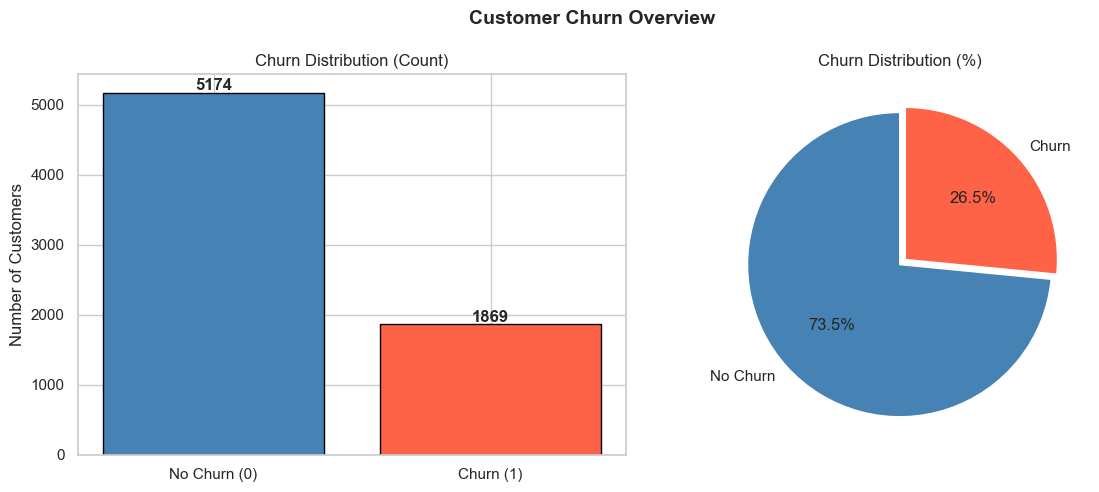

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df["Churn"].value_counts()
axes[0].bar(["No Churn (0)", "Churn (1)"], churn_counts.values,
            color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Churn Distribution (Count)")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(churn_counts.values, labels=["No Churn", "Churn"],
            autopct="%1.1f%%", colors=["steelblue", "tomato"],
            startangle=90, explode=(0, 0.05))
axes[1].set_title("Churn Distribution (%)")

plt.suptitle("Customer Churn Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Churn by Contract Type

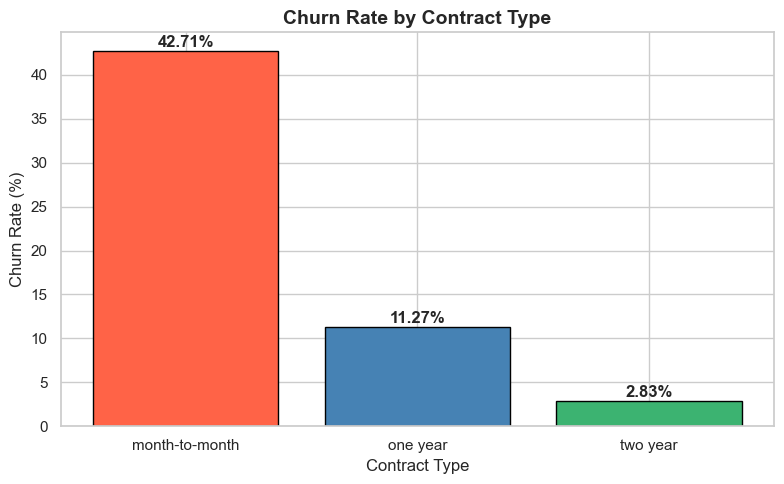

In [64]:
contract_churn = df.groupby("Contract")["Churn"].mean().reset_index()
contract_churn["Churn"] = (contract_churn["Churn"] * 100).round(2)
contract_churn = contract_churn.sort_values("Churn", ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(contract_churn["Contract"], contract_churn["Churn"],
               color=["tomato", "steelblue", "mediumseagreen"], edgecolor="black")
plt.title("Churn Rate by Contract Type", fontsize=14, fontweight="bold")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
for bar, val in zip(bars, contract_churn["Churn"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## Churn by Tenure Band

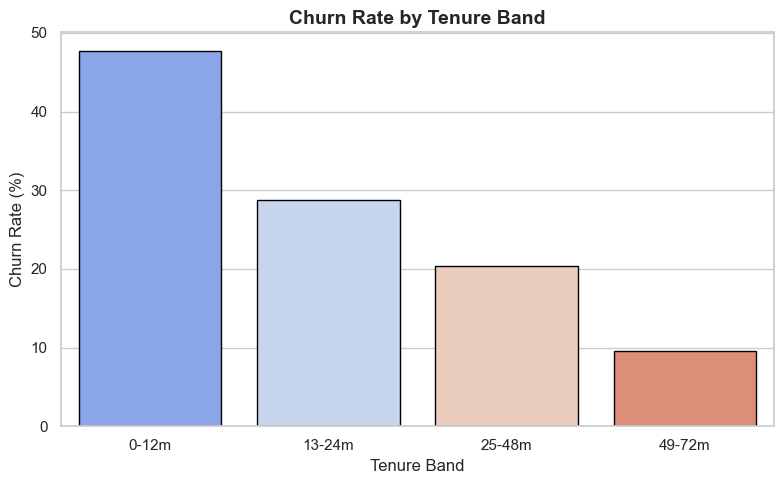

In [65]:
tenure_churn = df.groupby("tenure_band")["Churn"].mean().reset_index()
tenure_churn["Churn"] = (tenure_churn["Churn"] * 100).round(2)

plt.figure(figsize=(8, 5))
sns.barplot(data=tenure_churn, x="tenure_band", y="Churn",
            palette="coolwarm", edgecolor="black",
            order=["0-12m", "13-24m", "25-48m", "49-72m"])
plt.title("Churn Rate by Tenure Band", fontsize=14, fontweight="bold")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure Band")
plt.tight_layout()
plt.show()

## Monthly Charges Boxplot

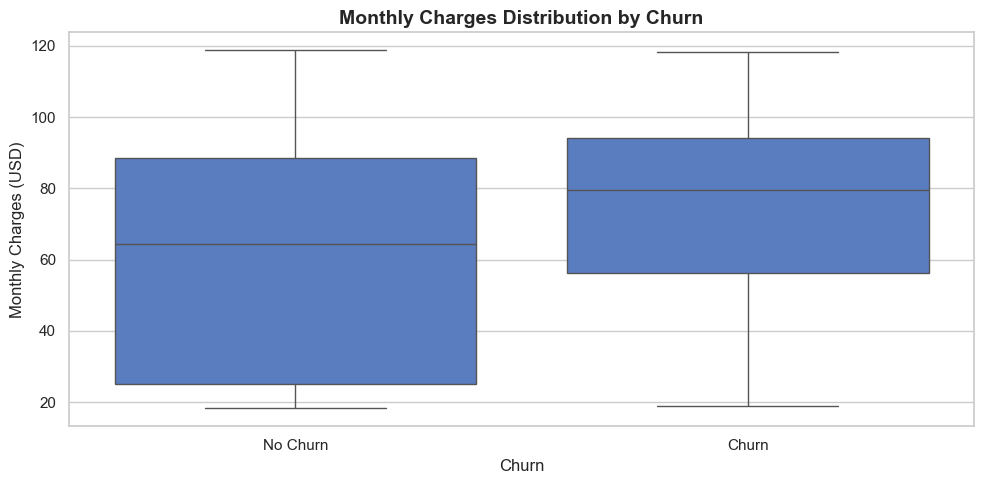

In [66]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.title("Monthly Charges Distribution by Churn", fontsize=14, fontweight="bold")
plt.ylabel("Monthly Charges (USD)")
plt.tight_layout()
plt.show()

## Correlation Heatmap

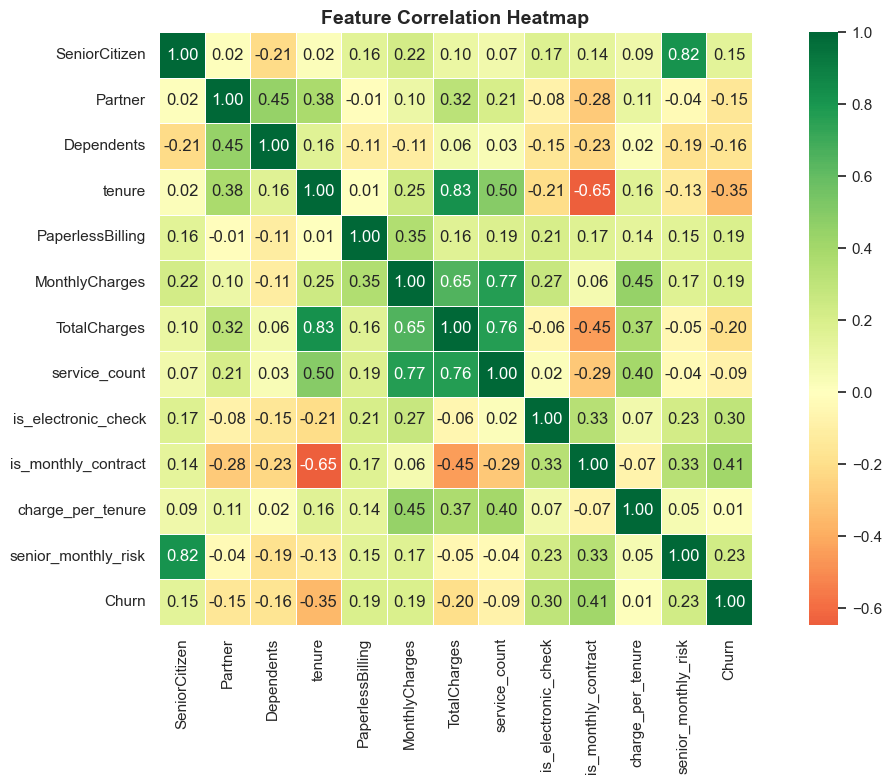

In [67]:
numeric_cols = [
    "SeniorCitizen", "Partner", "Dependents", "tenure",
    "PaperlessBilling", "MonthlyCharges", "TotalCharges",
    "service_count", "is_electronic_check", "is_monthly_contract",
    "charge_per_tenure", "senior_monthly_risk", "Churn"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, square=True)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---

## EDA Summary

From the exploratory analysis above, the key churn risk patterns are:

| Finding | Insight |
|---|---|
| **Month-to-month contracts** | Highest churn rate — customers with no long-term commitment leave easily |
| **Short tenure (0–12 months)** | New customers churn most — onboarding experience is critical |
| **High monthly charges** | Churners tend to pay more — perceived value may be low |
| **Electronic check payment** | Correlated with higher churn — possibly less engaged customer segment |
| **Fiber optic internet** | Higher churn than DSL — may indicate service quality issues |
| **No online security/support** | Customers with fewer add-ons have less stickiness |

> These patterns will inform our feature selection and model interpretation below.

# 3. Preprocessing

In [68]:
FEATURE_COLS = [
    "SeniorCitizen", "Partner", "Dependents", "tenure",
    "PaperlessBilling", "MonthlyCharges", "TotalCharges",
    "service_count", "is_electronic_check", "is_monthly_contract",
    "charge_per_tenure", "senior_monthly_risk"
]
TARGET_COL = "Churn"

# Drop rows with nulls in feature cols
df_model = df[FEATURE_COLS + [TARGET_COL]].dropna()

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Class imbalance ratio (for scale_pos_weight)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = round(neg / pos, 2)

# 4. Baseline (XGBoost) and Tuned (XGBoost)

## XGBoost

In [69]:
baseline_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),          # scale features
    ("classifier", XGBClassifier(          # XGBoost classifier
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        scale_pos_weight=scale_pos,
        eval_metric="logloss",
        random_state=42
    ))
])

# Fit pipeline on training data only — scaler fitted here, not on test data
baseline_pipeline.fit(X_train, y_train)

y_pred_base = baseline_pipeline.predict(X_test)
y_prob_base = baseline_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost Baseline Pipeline (Default Parameters)")
print(classification_report(y_test, y_pred_base, target_names=["No Churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_base):.4f}")

XGBoost Baseline Pipeline (Default Parameters)
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.8405


## Hyperparameter Tuning with Pipeline + GridSearchCV

We wrap the full pipeline inside **GridSearchCV** so that:
- The scaler is **re-fitted on each fold's training split only**
- No test fold data ever influences the scaler — preventing data leakage
- Hyperparameters are searched across the full pipeline

In [70]:
param_grid = {
    "classifier__n_estimators":     [100, 200, 300],
    "classifier__max_depth":        [3, 4, 5],
    "classifier__learning_rate":    [0.01, 0.05, 0.1],
}

tuned_pipeline = Pipeline(steps=[
    ("scaler",     StandardScaler()),
    ("classifier", XGBClassifier(
        scale_pos_weight=scale_pos,
        eval_metric="logloss",
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=tuned_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,       # use all CPU cores
    verbose=1,
    refit=True       # refit best pipeline on full X_train after search
)

In [71]:
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters:\n{grid_search.best_params_}")
print(f"\nBest CV ROC-AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits



Best Parameters:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}

Best CV ROC-AUC: 0.8423


In [72]:
best_pipeline = grid_search.best_estimator_

y_pred_tuned = best_pipeline.predict(X_test)
y_prob_tuned = best_pipeline.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Pipeline (GridSearchCV Best Parameters)")
print(classification_report(y_test, y_pred_tuned, target_names=["No Churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")

Tuned XGBoost Pipeline (GridSearchCV Best Parameters)
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.51      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.8398


## Model Comparison

In [73]:
from sklearn.metrics import f1_score, precision_score, recall_score

results = pd.DataFrame({
    "Model": [
        "XGBoost Baseline Pipeline",
        "XGBoost Tuned Pipeline (GridSearchCV)"
    ],
    "ROC-AUC": [
        round(roc_auc_score(y_test, y_prob_base), 4),
        round(roc_auc_score(y_test, y_prob_tuned), 4)
    ],
    "Precision (Churn)": [
        round(precision_score(y_test, y_pred_base), 4),
        round(precision_score(y_test, y_pred_tuned), 4)
    ],
    "Recall (Churn)": [
        round(recall_score(y_test, y_pred_base), 4),
        round(recall_score(y_test, y_pred_tuned), 4)
    ],
    "F1 (Churn)": [
        round(f1_score(y_test, y_pred_base), 4),
        round(f1_score(y_test, y_pred_tuned), 4)
    ]
})

print("=== Pipeline Model Comparison ===")
results

=== Pipeline Model Comparison ===


,Model,ROC-AUC,Precision (Churn),Recall (Churn),F1 (Churn)
0,XGBoost Baseline Pipeline,0.8405,0.5147,0.7941,0.6246
1,XGBoost Tuned Pipeline (GridSearchCV),0.8398,0.5147,0.7968,0.6254


## Confusion Matrix: Baseline vs Tuned Pipeline

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_base, y_pred_tuned],
    ["XGBoost Baseline Pipeline", "XGBoost Tuned Pipeline (GridSearchCV)"]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix\n{title}", fontweight="bold")

plt.tight_layout()
plt.show()